In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

pd.set_option("display.max_columns", None)

PROCESSED_DATA_DIR = Path("C:\\Users\\aabre\\Documents\\data-science-projects\\nba-player-archetype-clustering\\data\\processed\\2025_26")
FIGURES_DIR = Path("C:\\Users\\aabre\\Documents\\data-science-projects\\nba-player-archetype-clustering\\figures")
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

players = pd.read_csv(PROCESSED_DATA_DIR / "STYLE_FEATURES_V1.csv")
players.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PLAYER_ID                450 non-null    int64  
 1   PLAYER_NAME              450 non-null    str    
 2   USG_RATE                 450 non-null    float64
 3   TOUCHES_PER_100          450 non-null    float64
 4   POT_AST_PER_100          450 non-null    float64
 5   DRIVES_PER_100           450 non-null    float64
 6   CATCH_SHOOT_FGA_PER_100  450 non-null    float64
 7   PULL_UP_FGA_PER_100      450 non-null    float64
 8   PAINT_TOUCHES_PER_100    450 non-null    float64
 9   SCREEN_AST_PER_100       450 non-null    float64
 10  DEFLECTIONS_PER_100      450 non-null    float64
 11  STL_PCT                  450 non-null    float64
 12  BLK_PCT                  450 non-null    float64
 13  BOXOUTS_PER_100          450 non-null    float64
 14  PAINT_FGA_RATE           450 non-null

In [2]:
features = players.drop(["PLAYER_ID", "PLAYER_NAME"], axis=1).columns.to_list()

print(players[features].isna().sum())
print(np.isinf(players[features]).sum())
print(players[features].std())

USG_RATE                   0
TOUCHES_PER_100            0
POT_AST_PER_100            0
DRIVES_PER_100             0
CATCH_SHOOT_FGA_PER_100    0
PULL_UP_FGA_PER_100        0
PAINT_TOUCHES_PER_100      0
SCREEN_AST_PER_100         0
DEFLECTIONS_PER_100        0
STL_PCT                    0
BLK_PCT                    0
BOXOUTS_PER_100            0
PAINT_FGA_RATE             0
MIDRANGE_FGA_RATE          0
dtype: int64
USG_RATE                   0
TOUCHES_PER_100            0
POT_AST_PER_100            0
DRIVES_PER_100             0
CATCH_SHOOT_FGA_PER_100    0
PULL_UP_FGA_PER_100        0
PAINT_TOUCHES_PER_100      0
SCREEN_AST_PER_100         0
DEFLECTIONS_PER_100        0
STL_PCT                    0
BLK_PCT                    0
BOXOUTS_PER_100            0
PAINT_FGA_RATE             0
MIDRANGE_FGA_RATE          0
dtype: int64
USG_RATE                    0.053039
TOUCHES_PER_100            18.576337
POT_AST_PER_100             4.811384
DRIVES_PER_100              8.052690
CATCH_SHOOT_FG

In [3]:
X = players[features].copy()
X.shape

(450, 14)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns = features, index = players.index)

print(X_scaled_df.mean().round(2))
print(X_scaled_df.std().round(2))
X_scaled_df.head()

USG_RATE                   0.0
TOUCHES_PER_100           -0.0
POT_AST_PER_100           -0.0
DRIVES_PER_100            -0.0
CATCH_SHOOT_FGA_PER_100    0.0
PULL_UP_FGA_PER_100       -0.0
PAINT_TOUCHES_PER_100      0.0
SCREEN_AST_PER_100         0.0
DEFLECTIONS_PER_100       -0.0
STL_PCT                   -0.0
BLK_PCT                    0.0
BOXOUTS_PER_100            0.0
PAINT_FGA_RATE             0.0
MIDRANGE_FGA_RATE         -0.0
dtype: float64
USG_RATE                   1.0
TOUCHES_PER_100            1.0
POT_AST_PER_100            1.0
DRIVES_PER_100             1.0
CATCH_SHOOT_FGA_PER_100    1.0
PULL_UP_FGA_PER_100        1.0
PAINT_TOUCHES_PER_100      1.0
SCREEN_AST_PER_100         1.0
DEFLECTIONS_PER_100        1.0
STL_PCT                    1.0
BLK_PCT                    1.0
BOXOUTS_PER_100            1.0
PAINT_FGA_RATE             1.0
MIDRANGE_FGA_RATE          1.0
dtype: float64


,USG_RATE,TOUCHES_PER_100,POT_AST_PER_100,DRIVES_PER_100,CATCH_SHOOT_FGA_PER_100,PULL_UP_FGA_PER_100,PAINT_TOUCHES_PER_100,SCREEN_AST_PER_100,DEFLECTIONS_PER_100,STL_PCT,BLK_PCT,BOXOUTS_PER_100,PAINT_FGA_RATE,MIDRANGE_FGA_RATE
0,-0.942783,-0.505670,-0.645524,-0.910562,1.267531,-0.047780,-0.939171,-0.539604,-0.775523,-1.405032,-1.071490,-0.387096,-2.060258,-0.577309
1,0.189714,-0.098932,0.227509,0.894536,-0.678260,-0.313349,-0.502151,-0.699726,-0.839722,-0.629881,-0.898473,-0.946035,0.755379,-0.862930
2,0.529463,0.205146,-0.159975,-0.621380,-0.136145,0.246436,0.877706,0.090241,-1.566525,-0.839818,-0.462470,-0.469305,-0.069969,0.656446
3,-0.489784,-0.395123,-0.301470,-0.113743,1.304167,-0.149876,-1.029892,-0.665542,-0.738104,0.080673,-0.946918,-0.667978,-1.106922,-0.261020
4,0.095339,0.073847,-0.734166,0.302626,0.892055,0.165172,-0.723176,-0.345877,-1.231835,-0.969010,0.056580,-0.709764,-0.699021,0.445300


In [5]:
test_kmeans = KMeans(n_clusters=5, random_state=28, n_init=20)
test_labels = test_kmeans.fit_predict(X_scaled)
pd.Series(test_labels).value_counts().sort_index()

0    159
1    120
2     41
3     73
4     57
Name: count, dtype: int64

In [6]:
k_values = range(2, 13)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=28, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

k_results = pd.DataFrame({"k": k_values, "inertia": inertias, "silhouette_score": silhouette_scores})
k_results

,k,inertia,silhouette_score
0,2,4525.546387,0.329562
1,3,3395.213753,0.273125
2,4,3011.783635,0.224017
3,5,2785.833088,0.219348
4,6,2603.666369,0.192002
5,7,2446.801822,0.170076
6,8,2340.747802,0.167727
7,9,2239.782644,0.165657
8,10,2153.634834,0.165386
9,11,2066.158676,0.169200


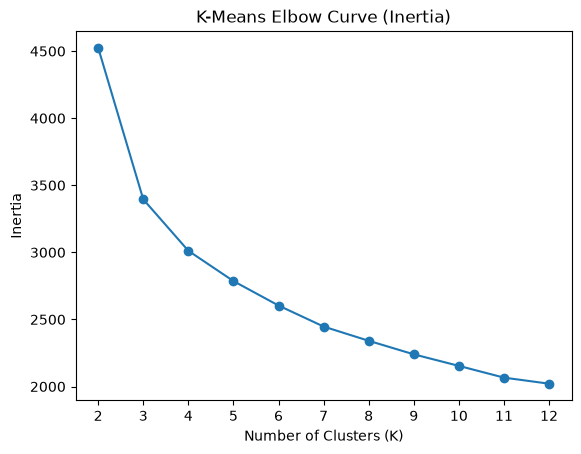

In [12]:
plt.plot(k_results["k"], k_results["inertia"], marker = "o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve (Inertia)")
plt.xticks(k_results["k"])
plt.show()

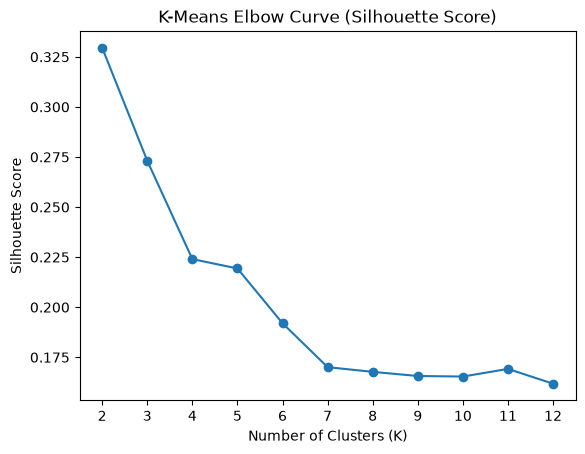

In [13]:
plt.plot(k_results["k"], k_results["silhouette_score"], marker = "o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Elbow Curve (Silhouette Score)")
plt.xticks(k_results["k"])
plt.show()

In [14]:
cluster_sizes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=28, n_init=20)
    labels = model.fit_predict(X_scaled)
    cluster_counts = pd.Series(labels).value_counts()
    cluster_sizes.append({"k": k, "smallest_cluster": cluster_counts.min(), "largest_cluster": cluster_counts.max()})

cluster_sizes = pd.DataFrame(cluster_sizes)
cluster_sizes

,k,smallest_cluster,largest_cluster
0,2,86,364
1,3,77,240
2,4,71,177
3,5,41,159
4,6,46,140
5,7,43,92
6,8,32,78
7,9,25,76
8,10,16,62
9,11,17,67


In [20]:
player_names = players[["PLAYER_ID", "PLAYER_NAME"]]
def player_lists(k, players = player_names, X_scaled = X_scaled):
    model = KMeans(n_clusters=k, random_state=28, n_init=20)
    labels = model.fit_predict(X_scaled)
    result = players.copy()
    result["CLUSTER"] = labels
    return model, result

In [23]:
model_k8, players_k8 = player_lists(8)

for cluster in sorted(np.unique(players_k8["CLUSTER"])):
    print("=" * 50)
    print(f"Cluster {cluster}")
    display(players_k8[players_k8["CLUSTER"] == cluster].head(25))

Cluster 0


,PLAYER_ID,PLAYER_NAME,CLUSTER
6,1642846,Ace Bailey,0
19,1629014,Anfernee Simons,0
33,1631097,Bennedict Mathurin,0
38,1626171,Bobby Portis Jr.,0
39,203992,Bogdan Bogdanović,0
43,1627742,Brandon Ingram,0
52,1642267,Bub Carrington,0
95,1629631,De'Andre Hunter,0
97,201942,DeMar DeRozan,0
109,1630170,Devin Vassell,0


Cluster 1


,PLAYER_ID,PLAYER_NAME,CLUSTER
1,1642358,AJ Johnson,1
2,203932,Aaron Gordon,1
4,1630174,Aaron Nesmith,1
5,1630598,Aaron Wiggins,1
16,1641748,Andre Jackson Jr.,1
18,203952,Andrew Wiggins,1
28,1630245,Ayo Dosunmu,1
44,1641706,Brandon Miller,1
46,1641729,Brice Sensabaugh,1
53,1627741,Buddy Hield,1


Cluster 2


...

,PLAYER_ID,PLAYER_NAME,CLUSTER
8,1642349,Ajay Mitchell,5
12,1630578,Alperen Sengun,5
13,1641708,Amen Thompson,5
20,1641710,Anthony Black,5
27,1630559,Austin Reaves,5
31,1642879,Ben Saraf,5
37,1631104,Blake Wesley,5
40,1630538,Bones Hyland,5
42,1641764,Brandin Podziemski,5
45,1630314,Brandon Williams,5


Cluster 6


,PLAYER_ID,PLAYER_NAME,CLUSTER
0,1631260,AJ Green,6
3,1628988,Aaron Holiday,6
14,1629599,Amir Coffey,6
30,1631248,Baylor Scheierman,6
32,1641767,Ben Sheppard,6
36,1642396,Blake Hinson,6
51,1631121,Bryce McGowens,6
62,1629661,Cameron Johnson,6
65,1642868,Carter Bryant,6
69,1642404,Chaz Lanier,6


Cluster 7


,PLAYER_ID,PLAYER_NAME,CLUSTER
9,201143,Al Horford,7
11,1642259,Alex Sarr,7
21,203076,Anthony Davis,7
25,1642854,Asa Newell,7
29,1628389,Bam Adebayo,7
41,1642382,Branden Carlson,7
48,201572,Brook Lopez,7
68,1643052,Chaney Johnson,7
70,1631096,Chet Holmgren,7
103,1642852,Derik Queen,7
